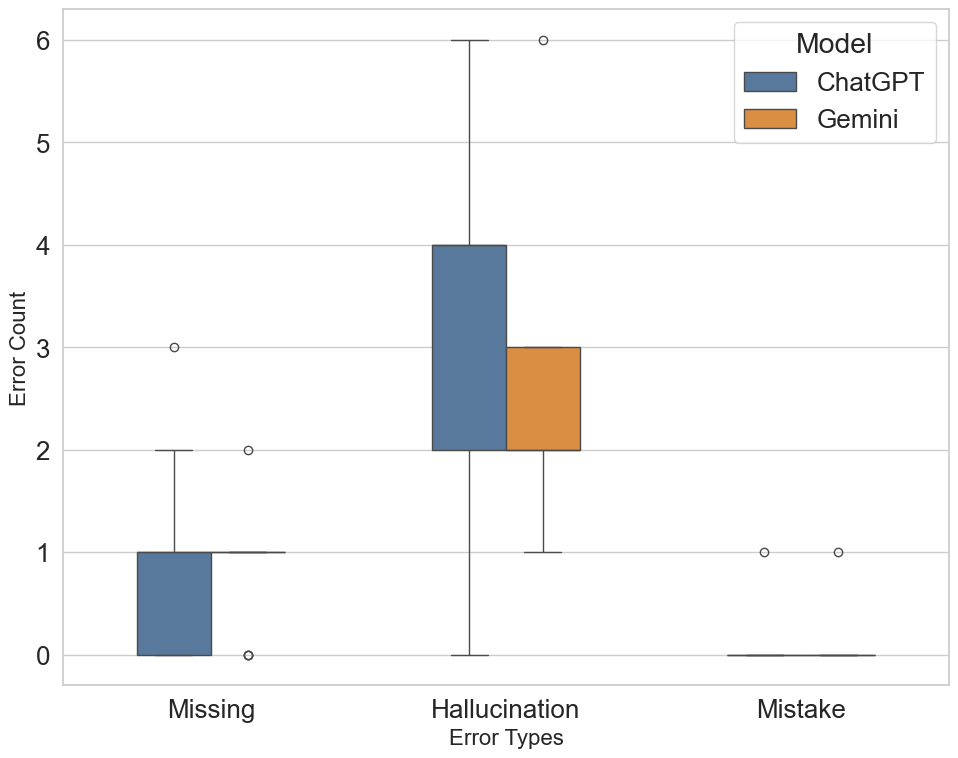

'boxplot_task3_style_errors.pdf'

In [2]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Load the new Excel file
file_path = 'Task_3_Summary.xlsx'
excel_data = pd.ExcelFile(file_path)

# Load each sheet
chatgpt_df = excel_data.parse('ChatGPT', header=1)
gemini_df  = excel_data.parse('Gemini', header=1)
# claude_df  = excel_data.parse('Claude', header=1)
# mistral_df = excel_data.parse('Mistral', header=1)

# Rename columns and add Model
chatgpt_df.columns = ['Code', 'Missing', 'Hallucination', 'Mistake']
gemini_df.columns  = ['Code', 'Missing', 'Hallucination', 'Mistake']
# claude_df.columns  = ['Code', 'Missing', 'Hallucination', 'Mistake']
# mistral_df.columns = ['Code', 'Missing', 'Hallucination', 'Mistake']

chatgpt_df['Model'] = 'ChatGPT'
gemini_df['Model']  = 'Gemini'
# claude_df['Model']  = 'Claude'
# mistral_df['Model'] = 'Mistral'

# Combine data
combined_df = pd.concat([chatgpt_df, gemini_df], ignore_index=True)
# combined_df = pd.concat([chatgpt_df, gemini_df, claude_df, mistral_df], ignore_index=True)

# Melt for plotting
melted_df = combined_df.melt(
    id_vars=['Model'],
    value_vars=['Missing', 'Hallucination', 'Mistake'],
    var_name='Error Type',
    value_name='Values'
)

# Custom colors
custom_palette = {
    'ChatGPT': '#4E79A7',
    'Gemini':  '#F28E2B',
    # 'Claude': '#E15759',
    # 'Mistral': '#76B7B2'
}

# Increase global font size
sns.set_theme(style="whitegrid", font_scale=1.7)

# Output PDF
pdf_out = "boxplot_task3_style_errors.pdf"

# -------------------------
# BOX PLOT (PDF)
# -------------------------
plt.figure(figsize=(10, 8))
ax = sns.boxplot(
    data=melted_df,
    x='Error Type',
    y='Values',
    hue='Model',
    palette=custom_palette,
    width=0.5,
    dodge=True
)

ax.set_xlabel('Error Types', fontsize=16)
ax.set_ylabel('Error Count', fontsize=16)

# Only integer ticks on Y axis
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(pdf_out, format='pdf')
plt.show()

pdf_out


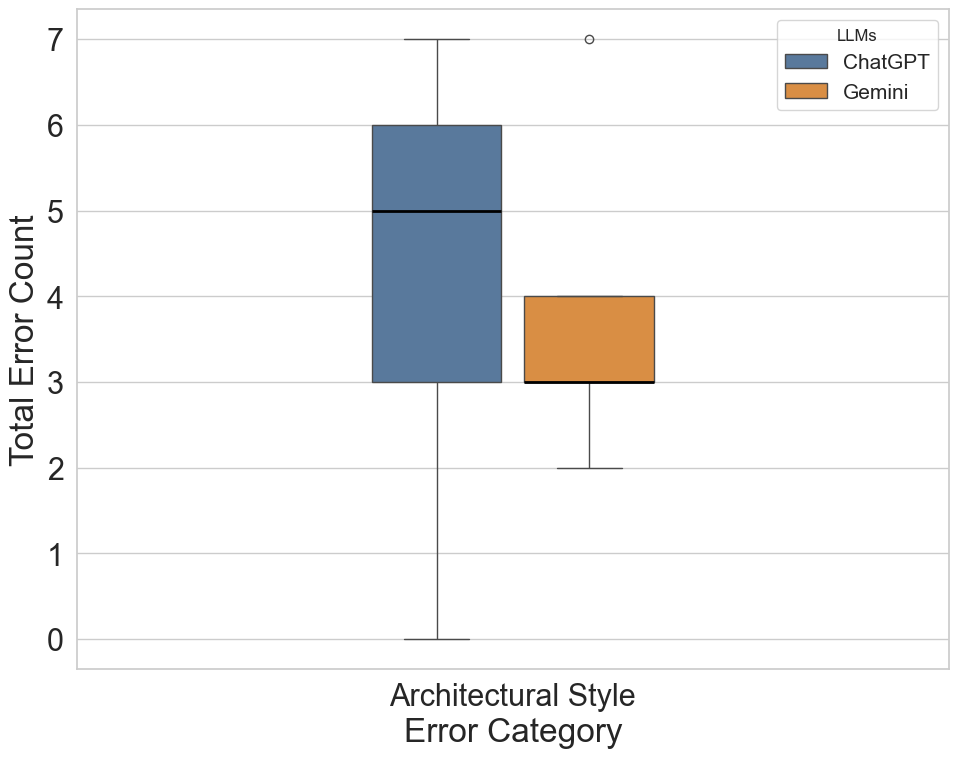

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Excel file
file_path = 'Task_3_Macro.xlsx'
excel_data = pd.ExcelFile(file_path)

# Prepare a combined DataFrame for plotting
combined_data = pd.DataFrame()

# Loop through each sheet and add the data to the combined DataFrame
for sheet in ['ChatGPT', 'Gemini']:
    df = excel_data.parse(sheet)
    # Adding a column to indicate the sheet name (source) for each row
    df['Source'] = sheet
    combined_data = pd.concat([combined_data, df[['Architectural Style', 'Source']]])

# Melt the combined data for easier box plotting
melted_data = pd.melt(
    combined_data,
    id_vars='Source',
    value_vars=['Architectural Style'],
    var_name='Metric',
    value_name='Value'
)

# Define custom color mapping for each source
color_palette = {
    'ChatGPT': '#4E79A7',
    'Gemini': '#F28E2B'
    # 'Claude': '#E15759',
    # 'Mistral': '#76B7B2'
}

# Plotting with custom colors
plt.figure(figsize=(10, 8))
sns.boxplot(
    data=melted_data,
    x='Metric',
    y='Value',
    hue='Source',
    gap=0.15,
    width=0.35,
    dodge=True,
    palette=color_palette,
    medianprops={"color": "black", "linewidth": 2}
)

plt.ylabel("Total Error Count", fontsize=24)
plt.xlabel("Error Category", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(title="LLMs", fontsize=15, title_fontsize=12)

plt.tight_layout()

# Save as PDF instead of PNG
output_file_path = 'macro_STYLE_box_plots_combined.pdf'
plt.savefig(output_file_path, format='pdf')

# Show plot
plt.show()
